# Rank Based Book Recommendation System

In this notebook, We implemented a rank-based recommendation approach
using the Goodreads (Goodbooks-10k) dataset.

This method recommends books based on their overall popularity
and average rating.

Rank-based recommendation is especially useful for solving
the Cold Start Problem, where a new user has no previous interaction history.

Dataset Link: https://www.kaggle.com/datasets/zygmunt/goodbooks-10k\

Group members: Vidhya Walke, Swarada Shirodkar

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
base_path = "/content/drive/MyDrive/Goodreads-Book-Recommendation-System/data/"

#datasets
books = pd.read_csv(base_path + "books.csv")
ratings = pd.read_csv(base_path + "ratings.csv")

print("Books dataset shape:", books.shape)
print("Ratings dataset shape:", ratings.shape)

Books dataset shape: (10000, 23)
Ratings dataset shape: (981756, 3)


In [25]:
books.head()

,id,book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,title,language_code,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,"The Hunger Games (The Hunger Games, #1)",eng,4.34,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,Harry Potter and the Sorcerer's Stone (Harry P...,eng,4.44,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,"Twilight (Twilight, #1)",en-US,3.57,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,To Kill a Mockingbird,eng,4.25,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,The Great Gatsby,eng,3.89,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...


In [26]:
ratings.head()

,book_id,user_id,rating
0,1,314,5
1,1,439,3
2,1,588,5
3,1,1169,4
4,1,1185,4


In [27]:
books.isnull().sum()

,0
id,0
book_id,0
best_book_id,0
work_id,0
books_count,0
isbn,700
isbn13,585
authors,0
original_publication_year,21
original_title,585


In [28]:
ratings.isnull().sum()

,0
book_id,0
user_id,0
rating,0


From the missing value analysis, We observe that the ratings dataset
does not contain significant missing values, which simplifies preprocessing.

# Rating Distribution

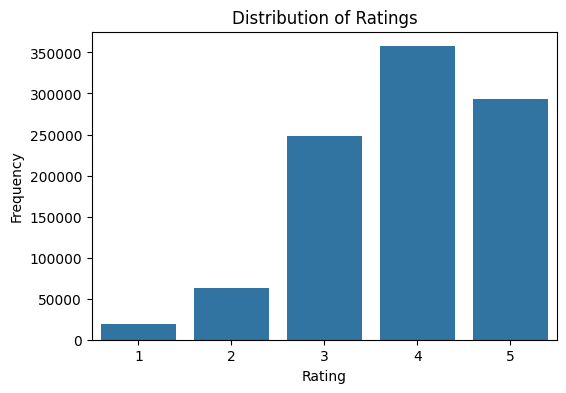

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(x='rating', data=ratings)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

The distribution shows that most ratings lie between 3 and 5,
indicating generally positive user feedback.

# Dataset Sparsity

In [30]:
num_users = ratings['user_id'].nunique()
num_books = ratings['book_id'].nunique()

total_possible = num_users * num_books
actual_ratings = len(ratings)

sparsity = 1 - (actual_ratings / total_possible)

print("Number of users:", num_users)
print("Number of books:", num_books)
print("Total possible interactions:", total_possible)
print("Actual ratings:", actual_ratings)
print("Sparsity:", sparsity)

Number of users: 53424
Number of books: 10000
Total possible interactions: 534240000
Actual ratings: 981756
Sparsity: 0.9981623315363881


The dataset is highly sparse, which is typical in recommendation systems.
Most user-book combinations do not have ratings.

# RANK BASED RECOMMENDATION

Compute Average Rating and Total Ratings

In [31]:
rank_df = ratings.groupby('book_id').agg(
    avg_rating=('rating', 'mean'),
    total_ratings=('rating', 'count')
).reset_index()

Merge With Book Titles

In [32]:
rank_df = rank_df.merge(
    books[['book_id', 'title']],
    on='book_id'
)

Sort Books

In [33]:
rank_df = rank_df.sort_values(
    by=['avg_rating', 'total_ratings'],
    ascending=False
)

rank_df.head(10)

,book_id,avg_rating,total_ratings,title
769,9566,4.777778,99,Still Life with Woodpecker
354,4708,4.660000,100,The Beautiful and Damned
771,9569,4.618557,97,Villa Incognito
762,9531,4.557143,70,Peter and the Shadow Thieves (Peter and the St...
291,3885,4.550000,100,The Taste of Home Cookbook
206,2767,4.540000,100,A People's History of the United States
448,5344,4.535354,99,Hard Times
210,2865,4.530000,100,Girl with a Pearl Earring
95,976,4.500000,100,Deception Point
786,9712,4.500000,94,Love in the Time of Cholera


# RECOMMENDATION FUNCTION

In [35]:
def get_top_books(n=5, min_ratings=100):
    """
    Recommend top N books based on:
    - High average rating
    - Minimum number of ratings

    This approach works well for new users.
    """

    filtered = rank_df[rank_df['total_ratings'] >= min_ratings]

    return filtered.head(n)

In [36]:
get_top_books()

,book_id,avg_rating,total_ratings,title
354,4708,4.66,100,The Beautiful and Damned
291,3885,4.55,100,The Taste of Home Cookbook
206,2767,4.54,100,A People's History of the United States
210,2865,4.53,100,Girl with a Pearl Earring
95,976,4.50,100,Deception Point


## Conclusion

In this notebook, We implemented a rank-based recommendation system.

This method:
- Is simple and efficient
- Works well for new users
- Does not require user similarity computation

However, it does not provide personalized recommendations.
To achieve personalization, collaborative filtering methods are required.